In [1]:
"""Imports principais para o notebook de detecção de fraudes:
carregamento e manipulação de dados, modelagem, avaliação,
balanceamento de classes e explicabilidade (SHAP)."""

# pylint: disable=line-too-long
import shap

from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pandas import DataFrame, Series
from numpy import dtype, ndarray

from imblearn.over_sampling import SMOTE
from shap import Explanation, Explainer

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings(action='ignore')


/home/diaspedro/Desktop/deteccao-fraudes-ml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("=== 1. Carregando dados ===")

URL = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"

df: DataFrame = pd.read_csv(filepath_or_buffer=URL)

print("Shape:", df.shape)
print(df.head())

=== 1. Carregando dados ===
Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.14126

In [3]:
print("\n=== 2. Verificando desbalanceamento ===")

print(df["Class"].value_counts(normalize=True))


=== 2. Verificando desbalanceamento ===
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [ ]:
print("\n=== 3. Feature Engineering ===")

df["Amount_log"] = np.log1p(df["Amount"])

scaler: StandardScaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

X: DataFrame = df.drop(labels="Class", axis=1)

y: Series = df["Class"]

X_TRAIN: DataFrame
Y_TRAIN: Series
X_TEST: DataFrame
Y_TEST: Series

X_TRAIN, X_TEST, Y_TRAIN, Y_TEST = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

print("Treino:", X_TRAIN.shape, "Teste:", X_TEST.shape)


=== 3. Feature Engineering ===
Treino: (199364, 32) Teste: (85443, 32)


In [5]:
print("\n=== 4. Regressão Logística baseline ===")

model: LogisticRegression = LogisticRegression(max_iter=10000)

model.fit(X=X_TRAIN, y=Y_TRAIN)

y_pred: ndarray[tuple[Any, ...], dtype[Any]] = model.predict(X=X_TEST)

print(classification_report(y_true=Y_TEST, y_pred=y_pred))


=== 4. Regressão Logística baseline ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.63      0.72       148

    accuracy                           1.00     85443
   macro avg       0.92      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443




=== 5. Curva ROC ===


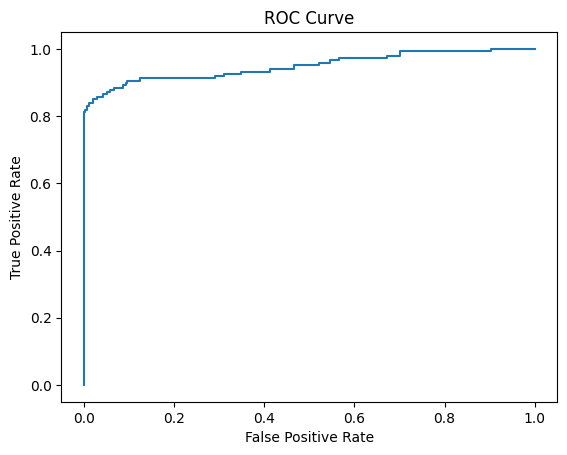

AUC: 0.9482997007207101


In [6]:
print("\n=== 5. Curva ROC ===")

y_probs: ndarray[tuple[Any, ...], dtype[Any]] = model.predict_proba(X=X_TEST)[:, 1]

fpr: ndarray[Any, dtype[Any]]
tpr: ndarray[Any, dtype[Any]]
_: ndarray[Any, dtype[Any]]

fpr, tpr, _ = roc_curve(y_true=Y_TEST, y_score=y_probs)

plt.plot(fpr, tpr)
plt.title(label="ROC Curve")
plt.xlabel(xlabel="False Positive Rate")
plt.ylabel(ylabel="True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_true=Y_TEST, y_score=y_probs))

In [7]:
print("\n=== 6. Undersampling manual ===")

fraudes: DataFrame = df[df["Class"] == 1]

normais: DataFrame = df[df["Class"] == 0].sample(n=len(fraudes), random_state=42)

df_under: DataFrame = pd.concat(objs=[fraudes, normais])

print("Tamanho undersampled:", len(df_under))


=== 6. Undersampling manual ===
Tamanho undersampled: 984


In [8]:
print("\n=== 7. Oversampling com SMOTE ===")

smote: SMOTE = SMOTE()

X_RES: DataFrame
Y_RES: DataFrame

X_RES, Y_RES = smote.fit_resample(X=X, y=y)  # type: ignore[assignment]

print("Tamanho após SMOTE:", len(X_RES))


=== 7. Oversampling com SMOTE ===
Tamanho após SMOTE: 568630


In [9]:
print("\n=== 8. Random Forest ===")

rf: RandomForestClassifier = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight="balanced", n_jobs=-1, random_state=42)

rf.fit(X=X_TRAIN, y=Y_TRAIN)

y_pred_rf: ndarray[tuple[Any, ...], dtype[Any]] = rf.predict(X=X_TEST)

print(classification_report(y_true=Y_TEST, y_pred=y_pred_rf))


=== 8. Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [10]:
print("\n=== 9. XGBoost ===")

xgb: XGBClassifier = XGBClassifier(scale_pos_weight=10, use_label_encoder=False, eval_metric="logloss")

xgb.fit(X=X_TRAIN, y=Y_TRAIN)

y_pred_xgb: ndarray[tuple[Any, ...], dtype[Any]] = xgb.predict(X=X_TEST)

print(classification_report(y_true=Y_TEST, y_pred=y_pred_xgb))


=== 9. XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.93      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.96      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



In [11]:
print("\n=== 10. Pipeline com LogisticRegression ===")

pipeline: Pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X=X_TRAIN, y=Y_TRAIN)

y_pred_pipe: ndarray[tuple[Any, ...], dtype[Any]] | tuple[ndarray[tuple[Any, ...], dtype[Any]], ndarray[tuple[Any, ...], dtype[Any]]] = pipeline.predict(X=X_TEST)

print(classification_report(y_true=Y_TEST, y_pred=y_pred_pipe))


=== 10. Pipeline com LogisticRegression ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.61      0.72       148

    accuracy                           1.00     85443
   macro avg       0.93      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



In [12]:
print("\n=== 11. Ajuste de THRESHOLD ===")

THRESHOLD: float = 0.3

y_pred_custom: ndarray[tuple[Any, ...], dtype[Any]] = (y_probs > THRESHOLD).astype(dtype=int)

print(classification_report(y_true=Y_TEST, y_pred=y_pred_custom))


=== 11. Ajuste de THRESHOLD ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.68      0.73       148

    accuracy                           1.00     85443
   macro avg       0.89      0.84      0.86     85443
weighted avg       1.00      1.00      1.00     85443



In [ ]:
print("\n=== 12. GridSearchCV ===")

param_grid: dict[str, list[int]] = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid: GridSearchCV = GridSearchCV(
    estimator=XGBClassifier(eval_metric="logloss"),
    param_grid=param_grid,
    scoring="recall",
    cv=3,
)

grid.fit(X=X_TRAIN, y=Y_TRAIN)

print("Melhores parâmetros:", grid.best_params_)


=== 12. GridSearchCV ===


In [ ]:
print("\n=== 13. SHAP ===")

explainer: Explainer = shap.Explainer(model=xgb)

shap_values: Explanation | list[Explanation] = explainer(X_TEST[:100])

shap.plots.bar(shap_values)

In [ ]:
print("\nTudo executado com sucesso!")